# 📈 Analisis Ketahanan Model GRU Menggunakan Data Skenario Sintetis

Notebook ini mengevaluasi **ketahanan (robustness)** model GRU terhadap gangguan permintaan pasar dengan melatih dan menguji model pada dataset skenario sintetis (data terganggu noise ±5%) yang dibuat di `generate_data.ipynb`.

Analisis ini membandingkan kinerja model pada tingkat Harian (Daily) dan Mingguan (Weekly) di bawah kondisi ketidakpastian permintaan logistik.

## 1. Impor Pustaka & Konfigurasi

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

torch.manual_seed(42)
np.random.seed(42)

## 2. Memuat Dataset Skenario Sintetis

In [2]:
src_path = 'data/processed/synthetic_cold_chain_data.csv'
df_synthetic = pd.read_csv(src_path)
df_synthetic['date'] = pd.to_datetime(df_synthetic['date'])
df_synthetic.set_index('date', inplace=True)

# Resample ke Mingguan untuk perbandingan
df_weekly_syn = df_synthetic.resample('W').agg({'demand': 'sum', 'ambient_temp': 'mean'})
df_weekly_syn['ambient_temp'] = df_weekly_syn['ambient_temp'].ffill().bfill()

print("=== RINGKASAN DATASET SKENARIO SINTETIS ===")
print(f"Daily   - Observasi: {{len(df_synthetic)}} hari | Mean Demand: {{df_synthetic['demand'].mean():.2f}}")
print(f"Weekly  - Observasi: {{len(df_weekly_syn)}} minggu | Mean Demand: {{df_weekly_syn['demand'].mean():.2f}}")

=== RINGKASAN DATASET SKENARIO SINTETIS ===
Daily   - Observasi: {len(df_synthetic)} hari | Mean Demand: {df_synthetic['demand'].mean():.2f}
Weekly  - Observasi: {len(df_weekly_syn)} minggu | Mean Demand: {df_weekly_syn['demand'].mean():.2f}


## 3. Fungsi Utility Pelatihan Model GRU (Sama dengan GRU-1)

In [3]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class GRUNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, num_layers=1, output_dim=1):
        super(GRUNet, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

def train_gru_model(df_agg, window_size, feature_cols, target_col='demand', epochs=120, batch_size=16):
    is_weekly = len(df_agg) >= 15 and len(df_agg) < 100
    scaler_features = MinMaxScaler()
    scaler_target = MinMaxScaler()
    
    features_scaled = scaler_features.fit_transform(df_agg[feature_cols].values)
    scaler_target.fit(df_agg[[target_col]].values)
    
    X, y = [], []
    for i in range(window_size, len(df_agg)):
        X.append(features_scaled[i-window_size:i])
        y.append(features_scaled[i, 0])
    X, y = np.array(X), np.array(y)
    
    indices = np.arange(len(X))
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
    
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    
    train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=batch_size, shuffle=False)
    
    model = GRUNet(input_dim=len(feature_cols), hidden_dim=16)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
    
    best_val_loss = float('inf')
    best_model_state = None
    
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            
        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                val_losses.append(criterion(model(batch_X), batch_y).item())
        val_loss = np.mean(val_losses)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_test, dtype=torch.float32)).numpy()
        
    preds_inv = np.clip(scaler_target.inverse_transform(preds).flatten(), 0.0, None)
    actuals_inv = scaler_target.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    mae = mean_absolute_error(actuals_inv, preds_inv)
    rmse = np.sqrt(mean_squared_error(actuals_inv, preds_inv))
    r2 = r2_score(actuals_inv, preds_inv)
    
    if is_weekly:
        valid = actuals_inv > 100
        if valid.sum() > 0:
            mape = mean_absolute_percentage_error(actuals_inv[valid], preds_inv[valid]) * 100.0
        else:
            mape = mean_absolute_percentage_error(actuals_inv, preds_inv) * 100.0
    else:
        non_zero = actuals_inv > 0
        mape = mean_absolute_percentage_error(actuals_inv[non_zero], preds_inv[non_zero]) * 100.0
    
    dates = df_agg.index[window_size:][test_idx]
    temps = df_agg['ambient_temp'].iloc[window_size:].iloc[test_idx].values
    df_res = pd.DataFrame({
        'date': dates,
        'actual': actuals_inv,
        'predicted': preds_inv,
        'ambient_temp': temps
    }).sort_values('date')
    
    return mae, rmse, mape, r2, df_res

## 4. Eksekusi Pelatihan Pada Data Skenario Sintetis

In [4]:
# 1. Daily Model (Synthetic)
df_synthetic['lag_1'] = df_synthetic['demand'].shift(1)
df_synthetic['lag_7'] = df_synthetic['demand'].shift(7)
df_synthetic['roll_mean_7'] = df_synthetic['demand'].rolling(7).mean()
df_synthetic['day_of_week'] = df_synthetic.index.dayofweek
df_synthetic['dow_sin'] = np.sin(2 * np.pi * df_synthetic['day_of_week'] / 7.0)
df_synthetic['dow_cos'] = np.cos(2 * np.pi * df_synthetic['day_of_week'] / 7.0)
df_synthetic = df_synthetic.bfill().ffill()
features_d = ['demand', 'ambient_temp', 'lag_1', 'lag_7', 'roll_mean_7', 'dow_sin', 'dow_cos']
mae_d, rmse_d, mape_d, r2_d, res_daily = train_gru_model(df_synthetic, window_size=7, feature_cols=features_d)

# 2. Weekly Model (Synthetic)
df_weekly_syn['lag_1'] = df_weekly_syn['demand'].shift(1)
df_weekly_syn['lag_4'] = df_weekly_syn['demand'].shift(4)
df_weekly_syn['roll_mean_4'] = df_weekly_syn['demand'].rolling(4).mean()
df_weekly_syn['month'] = df_weekly_syn.index.month
df_weekly_syn['month_sin'] = np.sin(2 * np.pi * df_weekly_syn['month'] / 12.0)
df_weekly_syn['month_cos'] = np.cos(2 * np.pi * df_weekly_syn['month'] / 12.0)
df_weekly_syn = df_weekly_syn.bfill().ffill()
features_w = ['demand', 'ambient_temp', 'lag_1', 'lag_4', 'roll_mean_4', 'month_sin', 'month_cos']
mae_w, rmse_w, mape_w, r2_w, res_weekly = train_gru_model(df_weekly_syn, window_size=4, feature_cols=features_w)

# Tabel Perbandingan Ketahanan Model
summary_data = {
    'Model (Scenario Data)': ['Daily (Harian Skenario)', 'Weekly (Mingguan Skenario)'],
    'MAE': [mae_d, mae_w],
    'RMSE': [rmse_d, rmse_w],
    'MAPE (%)': [mape_d, mape_w],
    'R2 Score': [r2_d, r2_w]
}
df_summary = pd.DataFrame(summary_data).set_index('Model (Scenario Data)')
print("\n=== TABEL PERBANDINGAN KETAHANAN MODEL GRU (DATA SKENARIO) ===")
display(df_summary.round(4))


=== TABEL PERBANDINGAN KETAHANAN MODEL GRU (DATA SKENARIO) ===


,MAE,RMSE,MAPE (%),R2 Score
Model (Scenario Data),,,,
Daily (Harian Skenario),38.3256,62.2439,59.0949,0.8821
Weekly (Mingguan Skenario),106.8166,123.5221,30.4772,0.9892


## 5. Visualisasi Hasil Aktual vs Prediksi (Data Skenario)

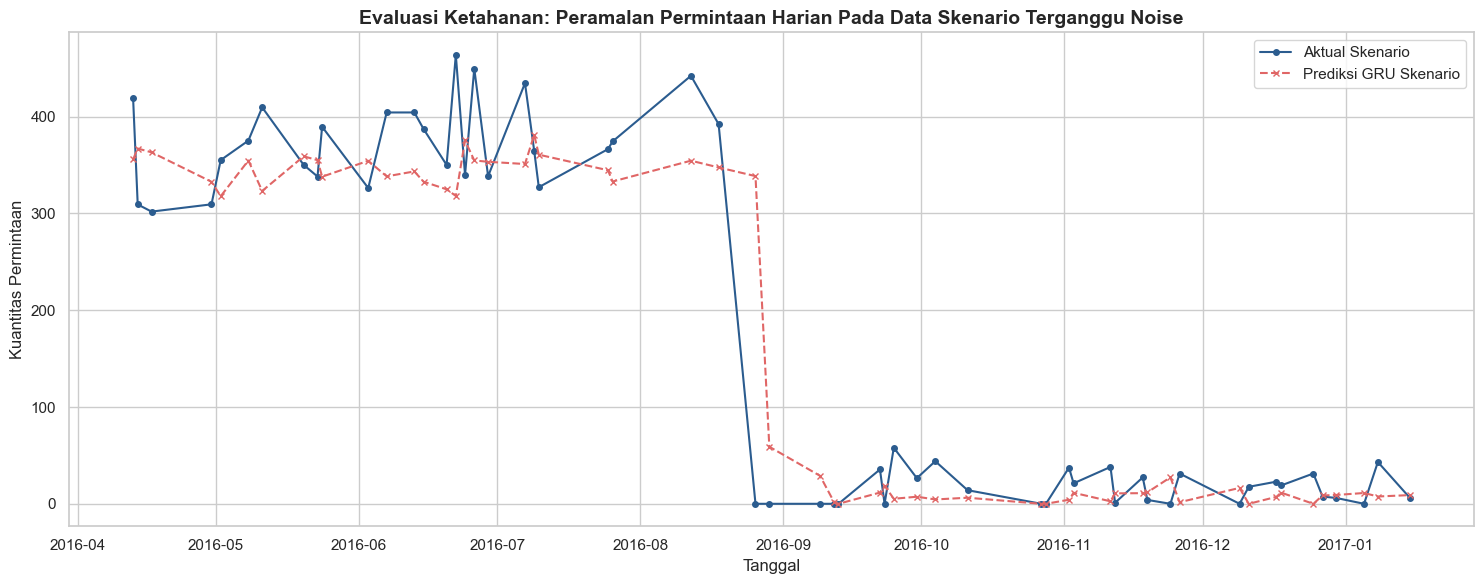

In [5]:
plt.figure(figsize=(15, 6))
plt.plot(res_daily['date'], res_daily['actual'], label='Aktual Skenario', color='#2b5c8f', marker='o', markersize=4)
plt.plot(res_daily['date'], res_daily['predicted'], label='Prediksi GRU Skenario', color='#e06666', linestyle='--', marker='x', markersize=4)
plt.title('Evaluasi Ketahanan: Peramalan Permintaan Harian Pada Data Skenario Terganggu Noise', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Kuantitas Permintaan')
plt.legend()
plt.tight_layout()
plt.show()